<h1>CUADERNO IA 2026 FUNDAMENTOS DE MACHINE LEARNING</h1><br>

<h1>NORMALIZACION</h1><br>

<img src="img/ITQ.png" alt="LOGO">

**Nombre:** *Gabriel Q. Pazmiño* <br>

**Fecha:** 05/05/2026 <br>

<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **

In [1]:
from sklearn import preprocessing
import numpy as np

In [2]:
# Carga de datos.
X_train = np.array([[ 1., -4.,  5.],
                    [ 5.,  0.,  2.],
                    [ 0.,  6., -3.]])

print(X_train)

[[ 1. -4.  5.]
 [ 5.  0.  2.]
 [ 0.  6. -3.]]


In [3]:
# Limpieza de datos: normalización.
normalizer = preprocessing.MinMaxScaler()
X_train_norm = normalizer.fit_transform(X_train)

In [4]:
# Salida de resultados.
print(X_train_norm)

[[0.2   0.    1.   ]
 [1.    0.4   0.625]
 [0.    1.    0.   ]]


In [5]:
# Ejemplo para ver que los resultados son iguales si aplicamos los métodos "fit" y "transform" por separado
X_train_2 = np.copy(X_train)

# Crea un objeto "fitted_normalizer" llamando al método "fit"
f = normalizer.fit(X_train)

# Aplica el objeto sobre los datos "X_train_2" para obtener "X_train_norm_2"
X_train_norm_2 = f.transform(X_train)

# Comprueba si "X_train_norm" y "X_train_norm_2" son iguales
print(np.array_equiv(X_train_norm, X_train_norm_2))
print(X_train_norm_2)

True
[[0.2   0.    1.   ]
 [1.    0.4   0.625]
 [0.    1.    0.   ]]


In [6]:
# Normalizar un nuevo conjunto de datos de test (SOLO HAY QUE APLICAR EL MÉTODO "transform", NO EL "fit")
X_test = np.array([[ 1., -3.,  2.],
                    [ 3.,  0.,  0.],
                    [ 0.,  4., -1.]])

# Normalizar los datos de "X_test"
X_test_norm=f.transform(X_test)

In [7]:
print(X_test_norm)

[[0.2   0.1   0.625]
 [0.6   0.4   0.375]
 [0.    0.8   0.25 ]]


<h1>ESTANDARIZACION</h1><br>

In [8]:
from sklearn import preprocessing
import numpy as np

In [9]:
# Carga de datos.
X_train = np.array([[ 1., -1.,  2.],
                    [ 2.,  0.,  0.],
                    [ 0.,  1., -1.]])

In [10]:
# Limpieza de datos: estandarización.
standardizer = preprocessing.StandardScaler()

# Estandarizamos los datos de entrenamiento
X_train_std=standardizer.fit_transform(X_train)
print(X_train_std)

[[ 0.         -1.22474487  1.33630621]
 [ 1.22474487  0.         -0.26726124]
 [-1.22474487  1.22474487 -1.06904497]]


In [11]:
X_train_2 = np.array([[ 1., -1.,  2.],
                    [ 2.,  0.,  0.],
                    [ 0.,  1., -1.]])

In [12]:
# Aplicamos los métodos "fit" y "transform" por separado
f=preprocessing.StandardScaler()
f=f.fit(X_train)
X_train_2_std = f.transform(X_train_2)
print(X_train_2_std)

[[ 0.         -1.22474487  1.33630621]
 [ 1.22474487  0.         -0.26726124]
 [-1.22474487  1.22474487 -1.06904497]]


In [13]:
# Comprobar si las matrices estandarizadas son iguales

# Compara ambas matrices elemento por elemento
# allclose devuelve True si son iguales (o muy similares por temas de decimales)
# Imprime en pantalla el resultado de la comparación
# True = son iguales
# False = hay diferencias
np.allclose(X_train_std, X_train_2_std)

True

## DETECCIÓN DE OUTLIERS

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

In [15]:
# Carga de datos.
df = pd.read_csv("dataset/outliers.csv")
print(df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


### 1) EllipticEnvelope()

In [16]:
# Entrenamos un objeto de tipo EllipticEnvelope
algorithm = EllipticEnvelope(support_fraction=None, contamination=0.25, random_state=42)
outlier_method = algorithm.fit(df)

# Aplicamos el método de detección de outliers entrenado sobre nuesto dataset devuelve una nueva columna
df_outliers = outlier_method.predict(df)
print(df_outliers)

# # Determinar la posición de los outliers
pos_outliers = np.where(df_outliers==-1)[0]
print('\nOutliers en la posición: \n', pos_outliers)

# # # Determinar el número de outliers
print('\nNúmero de outliers: \n', len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición: 
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


In [17]:
# Definimos una función que, dado un determinado "df" y un "algorithm", devuelva la matriz y la posición de outliers
def find_outliers(df, algorithm):

    #Caso especial: LocalOutlierFactor
    if algorithm.__class__.__name__ == "LocalOutlierFactor":
        df_outliers = algorithm.fit_predict(df)
    else:
        #Para otros algoritmos
        outlier_method = algorithm.fit(df)
        #Aplicacmos el método de detección de outliers entrenado sobre nuestro dataset
        df_outliers = outlier_method.predict(df)  
    
    print(df_outliers)
    #determinamos la posicion de los outliers
    pos_outliers=np.where(df_outliers==-1)[0]
    print('\nOutliers en la posición :\n', pos_outliers)
    #Determinamos el número de outliers
    print('\nNúmero de outliers: \n', len(pos_outliers))
          
    return df_outliers, pos_outliers

### 2) Otros métodos similares

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

IF = IsolationForest(max_samples='auto', random_state=42)
OC_SVM = OneClassSVM(kernel="poly",degree=1, gamma="auto")
LOF = LocalOutlierFactor(n_neighbors=10, algorithm="auto", metric="euclidean")

df_outliers, pos_outliers = find_outliers(df,OC_SVM)
print(len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1  1 -1 -1  1  1 -1 -1  1  1 -1 -1
  1  1 -1  1  1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1 -1 -1 -1 -1
  1  1 -1  1 -1 -1  1 -1]

Outliers en la posición :
 [151 152 153 154 155 156 158 159 162 163 166 167 170 179 180 182 183 188
 189 190 191 194 196 197 199]

Número de outliers: 
 25
25


In [19]:
df.head(10)

,a,b
0,0.149014,-0.041479
1,0.194307,0.456909
2,-0.070246,-0.070241
3,0.473764,0.230230
4,-0.140842,0.162768
5,-0.139025,-0.139719
6,0.072589,-0.573984
7,-0.517475,-0.168686
8,-0.303849,0.094274
9,-0.272407,-0.423691


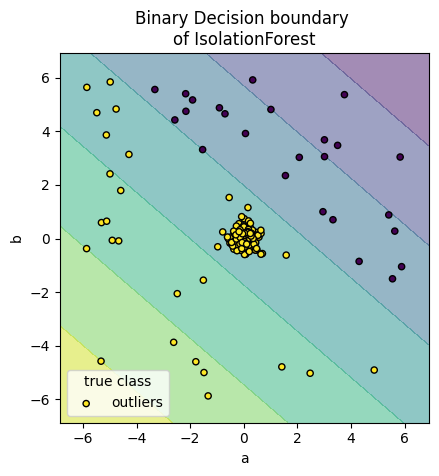

In [20]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    OC_SVM,
    df,
    response_method = "decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a,df.b,c=df_outliers,s=20,edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(labels=["outliers","inliers"], title="true class")
plt.show()

In [21]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
187 -4.589685  1.790524
192 -5.854146  5.638546
193 -5.482081  4.693717
195 -5.114441  0.646251
198 -0.545507  1.530697

[175 rows x 2 columns]


### 3) Box plot

limite inferior:  -1.0853060827395105
limite superior:  1.0119554520872196
Posición de outliers:  [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


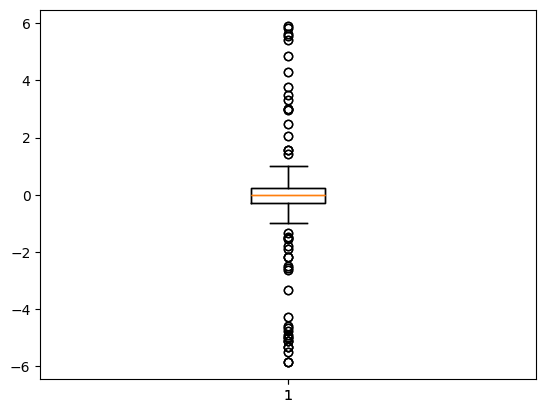

In [22]:
# Seleccionamos el atributo que vamos a medir
a = df['a']

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1
li = Q1 - 1.5*RIC #xmin
ls = Q3 + 1.5*RIC #xmax

# Observamos los límites inferior y superior
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos la posición de los outliers
pos_i = np.where(a<li)[0]
pos_s = np.where(a>ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))
print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()

In [23]:
# Definir una función que, dada una columna de un dataframe, devuelva la posición de los outliers según el método box plot
def find_limits_BP(variable):
    
    # ???
    
    return pos_outliers


In [24]:
# Creamos un bucle for que estime los valores outliers de cada atributo
headers = df.columns
pos_outliers = []

for i in range(len(headers)):
    variable = df[headers[i]]
    
    # Convertimos la salida en array columna
    pos_out = np.array(find_limits_BP(variable)).reshape(-1,1)
    
    pos_outliers.append(pos_out)

# Concatenamos todas las posiciones de outliers
po = np.vstack(pos_outliers)

# Vemos las posiciones de todos los outliers
pos_out = np.unique(po)

print('Posiciones de outliers: ', pos_out)

# Observamos el número de outliers
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  []
Numero de outliers:  0


# Ejercicio Ejercicio Practico
### Fecha: 05/05/2026


# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Objetivo General
Aplicar Técnicas de normalización y estandarización de datos mediante herramientas de python, con el fin de comprender su impacto en la prepación de datos y en el desempeño de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Escenario de práctica
Una empresa de análisis de datos desea desarrollar modelos predictivos utilizando información de clientes. Sin embargo, se ha identificado que las variables presentan diferentes escalas, lo que puede afectar el rendimiento de los modelos.<br>
Se soliciata al analista aplicar tecnicas de preprocesamiento y limpieza de datos para mejorar la calidad de lso datos.<br>
## Conjunto de datos  utilizar
Dataset 1(Conceptual): Iris dataset <br>
Dataset 2 (aplicación real): California Housing Dataset<br>



In [25]:
#Importacion de librerias 
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [26]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/ESTUDIANTES-ITQ/Desktop/cuadernoIA2026/cuadernoIA2026/.kaggle"

In [27]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [28]:
#Descargamos el dataset
!kaggle datasets download -d uciml/iris


Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
iris.zip: Skipping, found more recently modified local copy (use --force to force download)


In [29]:
#Descompriminos el archivo 
with zipfile.ZipFile("iris.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [30]:
#Cargamos el conjunto de datos
df = pd.read_csv("dataset/Iris.csv")

In [31]:
#mostramos el conjunto de datos"
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
#Eliminamos columnas innecesarias en la limpieza de datos como vemos en el dataframe la columna id no aporta
#nada a nuestro modelo por lo tanto lo eliminamos 
if 'Id' in df.columns:
    df=df.drop(columns=["Id"])



In [33]:
#Mostramos los detalles de nuesto dataset
df.info()
#Vrificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [34]:
#Separamos los datos de entrada con nuestra variable objetivo 
X=df.drop(columns=['Species'])
y=df['Species']

In [35]:
#Exploramos o generamos un analis exploratorio del conjutno de datos
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Conclusión 
Cuando observamso la tabla, lo primero que se observa es que cada variable tiene valores diferentes en tamaño y rango<b>
Por ejemplo<br>
* **PetalLengthCm** tiene valores desde 1.0 hasta 6.9, lo que significa que varia bastante
* En cambio, **SepalWidthCm** va aproximadamente de 2.0 a 4.4 es decir, tiene meno variación.
Esto nos dice que no todas las variables están en la misma escala.
### Qué significa?
Al ver los datos vemos que algunas variables tiene números más grandes que otras, y en modelos como KNN.<br>
* Los números grandes "pesan más"
* Influyen mas en el resultado.
Sino hacemos nada y trabajamos con estos datos el mnodelo va a tomas decisiones basadas en el argumeto **PetalLengtnCm** y menos en otras variables.Esto no es lo conveniento y a esto lo llamamos sesgo.<br>
Para no tener sesgo dentro de nuestros datos lo que hacemso es:
* Normalización
* Estandarización
Esto permite que las variables esten en la misma celda y tengan la misma importancia.


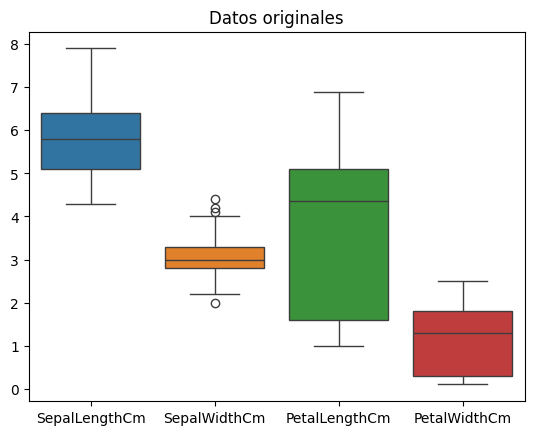

In [36]:
#dibujamso los datos originales 
sns.boxplot(data=X)
#Ponemos un titulo a la imagen 
plt.title("Datos originales")
plt.show()

## Interpretación de la imagen 
Este gráfico nos permite observar que los datos no están en la misma escala y que algunas variables tienen mayor variabilidad que otras. Esto puede afectar el comportamiento de los modeos de inteligencia artifical, por lo que es necesario aplicar técnicas como la normalización o estandarización para equilibrar la influencia de todas las varaibles.


In [37]:
#Normalizamos el conjunto de datos 
normalizer = preprocessing.MinMaxScaler()
X_norm=normalizer.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
X_norm.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [38]:
X_norm.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [39]:
#Estandarización 
standarizer = preprocessing.StandardScaler()
#Estandarizamos los datos
X_std=standarizer.fit_transform(X)
X_std= pd.DataFrame(X_std, columns=X.columns)
X_std.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


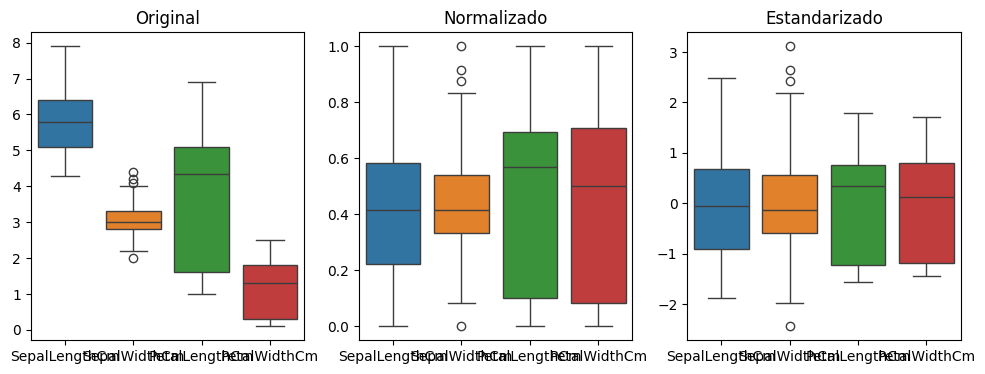

In [40]:
#Comporación visual
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=X)
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(data=X_norm)
plt.title("Normalizado")

plt.subplot(1,3,3)
sns.boxplot(data=X_std)
plt.title("Estandarizado")

plt.show()

# Ejercicio Deber Análisis de datos clínicos para la detección de enfermedades cardíacas


![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 06/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **

# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
## Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [41]:
# Importamos las librerias de sklearn para este caso
import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [90]:
# Configuramos el ambiente para descarga del archivo en Kaggle
import os
os.environ['KAGGLE_CONFIG_DIR'] = "C:/Users/ESTUDIANTES-ITQ/Desktop/cuadernoIA2026/cuadernoIA2026/.kaggle"

In [91]:
# Crear carpeta para dataset
os.makedirs("dataset_heart", exist_ok=True)

In [92]:
# Descargar dataset de enfermedades cardíacas
!kaggle datasets download -d johnsmith88/heart-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [93]:
# Descomprimir archivo
with zipfile.ZipFile("heart-disease-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_heart")

In [94]:
# Cargar el dataset
df = pd.read_csv("dataset_heart/heart.csv")

In [95]:
# Mostrar primeras filas
print("=== PRIMERAS FILAS DEL DATASET ===")
df.head()

=== PRIMERAS FILAS DEL DATASET ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [96]:
# Mostramos la información general del dataset
print("\n=== INFORMACIÓN DEL DATASET ===")
df.info()

# Verificamos si existen valores nulos en cada columna
print("\n=== VERIFICACIÓN DE VALORES NULOS ===")
print(df.isnull().sum())

# Mostramos las estadísticas descriptivas de los datos numéricos
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

# Analizamos la distribución de la variable objetivo (target)
print("\n=== DISTRIBUCIÓN DE ENFERMEDAD CARDÍACA ===")
print(df['target'].value_counts())

# Calculamos el porcentaje de personas con enfermedad cardíaca
print(f"Porcentaje con enfermedad: {df['target'].mean()*100:.2f}%")


=== INFORMACIÓN DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

=== VERIFICACIÓN DE VALORES NULOS ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
c

In [97]:
# Separar variables numéricas (excluyendo la target)
X = df.drop('target', axis=1)
y = df['target']

In [98]:
# Mostramos los rangos de cada variable
print("\n=== RANGOS DE VARIABLES NUMÉRICAS ===")
for col in X.columns:
    print(f"{col:20s} | min: {X[col].min():8.2f} | max: {X[col].max():8.2f} | rango: {X[col].max()-X[col].min():8.2f}")


=== RANGOS DE VARIABLES NUMÉRICAS ===
age                  | min:    29.00 | max:    77.00 | rango:    48.00
sex                  | min:     0.00 | max:     1.00 | rango:     1.00
cp                   | min:     0.00 | max:     3.00 | rango:     3.00
trestbps             | min:    94.00 | max:   200.00 | rango:   106.00
chol                 | min:   126.00 | max:   564.00 | rango:   438.00
fbs                  | min:     0.00 | max:     1.00 | rango:     1.00
restecg              | min:     0.00 | max:     2.00 | rango:     2.00
thalach              | min:    71.00 | max:   202.00 | rango:   131.00
exang                | min:     0.00 | max:     1.00 | rango:     1.00
oldpeak              | min:     0.00 | max:     6.20 | rango:     6.20
slope                | min:     0.00 | max:     2.00 | rango:     2.00
ca                   | min:     0.00 | max:     4.00 | rango:     4.00
thal                 | min:     0.00 | max:     3.00 | rango:     3.00


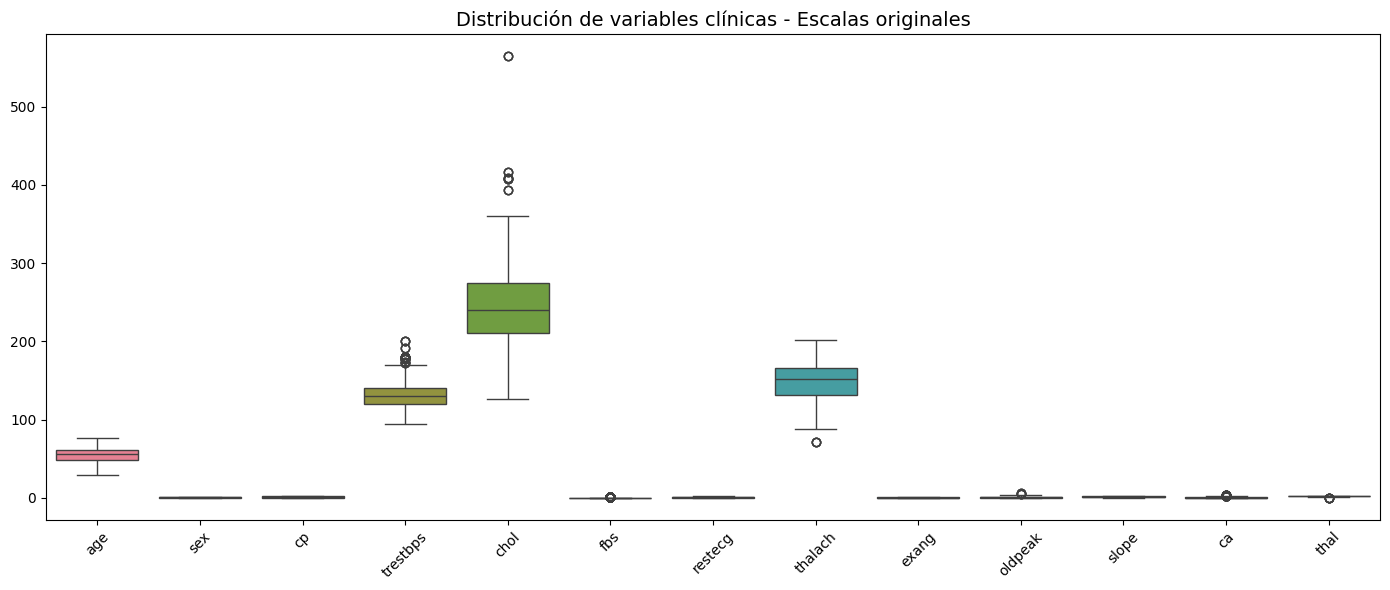

In [51]:
# Creamos una figura para visualizar los datos
plt.figure(figsize=(14, 6))

# Generamos un boxplot para observar la distribución
# de las variables clínicas en su escala original
sns.boxplot(data=X)

# Agregamos título al gráfico
plt.title("Distribución de variables clínicas - Escalas originales", fontsize=14)

# Rotamos los nombres de las variables para mejor visualización
plt.xticks(rotation=45)

# Ajustamos automáticamente los espacios del gráfico
plt.tight_layout()

# Mostramos el gráfico
plt.show()

In [52]:
# Aplicamos la normalización Min-Max:
# transforma los datos a una escala entre 0 y 1
# usando los valores mínimo y máximo de cada variable
normalizer = preprocessing.MinMaxScaler()

# Ajustamos y transformamos los datos
X_norm = normalizer.fit_transform(X)

# Convertimos el resultado nuevamente en DataFrame
X_norm = pd.DataFrame(X_norm, columns=X.columns)

# Mostramos estadísticas de los datos normalizados
print("\n=== DATOS NORMALIZADOS (Min-Max) ===")
print(X_norm.describe())


=== DATOS NORMALIZADOS (Min-Max) ===
               age          sex           cp     trestbps         chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.529878     0.695610     0.314146     0.354827     0.273973   
std       0.189006     0.460373     0.343214     0.165252     0.117791   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.395833     0.000000     0.000000     0.245283     0.194064   
50%       0.562500     1.000000     0.333333     0.339623     0.260274   
75%       0.666667     1.000000     0.666667     0.433962     0.340183   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.264878     0.596291     0.336585     0.172825   
std       0.356527     0.263939     0.175616     0.472772     0.189525   

In [53]:
# Aplicamos la estandarización Z-score:
# transforma los datos para que cada variable tenga:
# Media ≈ 0 y Desviación estándar ≈ 1
standardizer = preprocessing.StandardScaler()

# Ajustamos y transformamos los datos
X_std = standardizer.fit_transform(X)

# Convertimos el resultado nuevamente en DataFrame
X_std = pd.DataFrame(X_std, columns=X.columns)

# Mostramos estadísticas de los datos estandarizados
print("\n=== DATOS ESTANDARIZADOS (Z-score) ===")
print(X_std.describe())


=== DATOS ESTANDARIZADOS (Z-score) ===
                age           sex            cp      trestbps          chol  \
count  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03   
mean  -3.431402e-16  1.802352e-16  5.545699e-17 -7.036106e-16 -3.466062e-18   
std    1.000488e+00  1.000488e+00  1.000488e+00  1.000488e+00  1.000488e+00   
min   -2.804866e+00 -1.511706e+00 -9.157554e-01 -2.148237e+00 -2.327054e+00   
25%   -7.095548e-01 -1.511706e+00 -9.157554e-01 -6.632165e-01 -6.787242e-01   
50%    1.726817e-01  6.615041e-01  5.593123e-02 -9.205458e-02 -1.163527e-01   
75%    7.240794e-01  6.615041e-01  1.027618e+00  4.791073e-01  5.623715e-01   
max    2.488552e+00  6.615041e-01  1.999305e+00  3.906079e+00  6.166694e+00   

                fbs       restecg       thalach         exang       oldpeak  \
count  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03   
mean  -4.159275e-17 -8.318549e-17 -4.332578e-16 -7.625337e-17 -2.426243e-16   
std    1.00

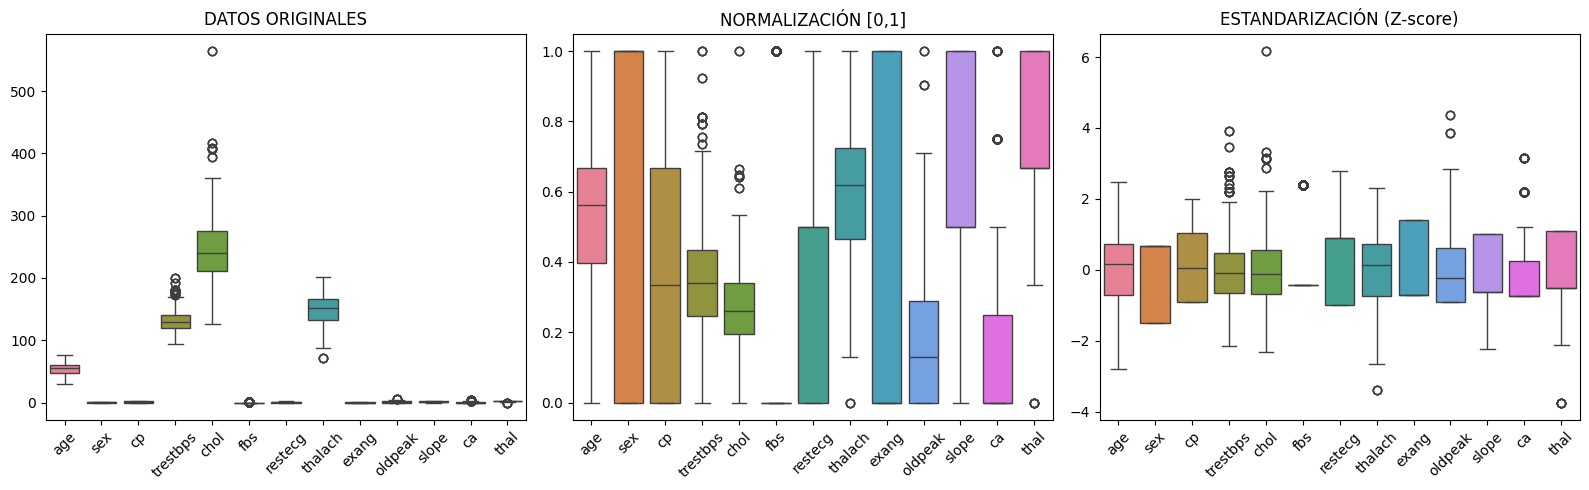

In [54]:
# Creamos una figura grande para comparar los tres conjuntos de datos
plt.figure(figsize=(16, 5))

# ---------------- DATOS ORIGINALES ----------------
# Primer gráfico: datos sin transformación
plt.subplot(1, 3, 1)
sns.boxplot(data=X)

# Título del gráfico
plt.title("DATOS ORIGINALES", fontsize=12)

# Rotamos etiquetas para mejor visualización
plt.xticks(rotation=45)

# ---------------- DATOS NORMALIZADOS ----------------
# Segundo gráfico: datos normalizados en rango [0,1]
plt.subplot(1, 3, 2)
sns.boxplot(data=X_norm)

# Título del gráfico
plt.title("NORMALIZACIÓN [0,1]", fontsize=12)

# Rotamos etiquetas
plt.xticks(rotation=45)

# ---------------- DATOS ESTANDARIZADOS ----------------
# Tercer gráfico: datos estandarizados con Z-score
plt.subplot(1, 3, 3)
sns.boxplot(data=X_std)

# Título del gráfico
plt.title("ESTANDARIZACIÓN (Z-score)", fontsize=12)

# Rotamos etiquetas
plt.xticks(rotation=45)

# Ajustamos automáticamente el espacio entre gráficos
plt.tight_layout()

# Mostramos la visualización completa
plt.show()

In [55]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
# 70% para entrenamiento y 30% para prueba
# stratify=y mantiene la proporción de clases de la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ---------------- NORMALIZACIÓN ----------------
# Aplicamos normalización Min-Max a los datos
# Escala los valores en un rango entre [0,1]

# Ajustamos y transformamos los datos de entrenamiento
X_train_norm = normalizer.fit_transform(X_train)

# Transformamos los datos de prueba usando los mismos parámetros
X_test_norm = normalizer.transform(X_test)

# ---------------- ESTANDARIZACIÓN ----------------
# Aplicamos estandarización Z-score
# Media ≈ 0 y desviación estándar ≈ 1

# Ajustamos y transformamos los datos de entrenamiento
X_train_std = standardizer.fit_transform(X_train)

# Transformamos los datos de prueba usando los mismos parámetros
X_test_std = standardizer.transform(X_test)

# Función para entrenar y evaluar modelos
def evaluar_modelo(nombre, X_train_data, X_test_data, y_train, y_test):
    
    # ---------------- KNN ----------------
    # Creamos el modelo KNN con 5 vecinos
    knn = KNeighborsClassifier(n_neighbors=5)
    
    # Entrenamos el modelo
    knn.fit(X_train_data, y_train)
    
    # Realizamos predicciones
    y_pred_knn = knn.predict(X_test_data)
    
    # Calculamos la precisión del modelo
    acc_knn = accuracy_score(y_test, y_pred_knn)
    
    # -------- REGRESIÓN LOGÍSTICA --------
    # Creamos el modelo de Regresión Logística
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    
    # Entrenamos el modelo
    logreg.fit(X_train_data, y_train)
    
    # Realizamos predicciones
    y_pred_log = logreg.predict(X_test_data)
    
    # Calculamos la precisión del modelo
    acc_log = accuracy_score(y_test, y_pred_log)
    
    # Mostramos los resultados obtenidos
    print(f"\n--- {nombre} ---")
    print(f"KNN - Precisión: {acc_knn:.4f}")
    print(f"Regresión Logística - Precisión: {acc_log:.4f}")
    
    # Retornamos las precisiones de ambos modelos
    return acc_knn, acc_log

# ---------------- COMPARACIÓN DE MODELOS ----------------
# Evaluamos el rendimiento usando:
# datos originales, normalizados y estandarizados

print("\n" + "="*50)
print("COMPARACIÓN DE RENDIMIENTO DE MODELOS")
print("="*50)

# Diccionario para almacenar resultados
resultados = {}

# Evaluación con datos originales
resultados['Original'] = evaluar_modelo(
    'DATOS ORIGINALES',
    X_train,
    X_test,
    y_train,
    y_test
)

# Evaluación con datos normalizados
resultados['Normalizado'] = evaluar_modelo(
    'DATOS NORMALIZADOS',
    X_train_norm,
    X_test_norm,
    y_train,
    y_test
)

# Evaluación con datos estandarizados
resultados['Estandarizado'] = evaluar_modelo(
    'DATOS ESTANDARIZADOS',
    X_train_std,
    X_test_std,
    y_train,
    y_test
)


COMPARACIÓN DE RENDIMIENTO DE MODELOS

--- DATOS ORIGINALES ---
KNN - Precisión: 0.7013
Regresión Logística - Precisión: 0.8247

--- DATOS NORMALIZADOS ---
KNN - Precisión: 0.8312
Regresión Logística - Precisión: 0.8344

--- DATOS ESTANDARIZADOS ---
KNN - Precisión: 0.8669
Regresión Logística - Precisión: 0.8182



=== TABLA COMPARATIVA DE PRECISIONES ===
                Modelo  Original  Normalizado  Estandarizado
0                  KNN  0.701299     0.831169       0.866883
1  Regresión Logística  0.824675     0.834416       0.818182


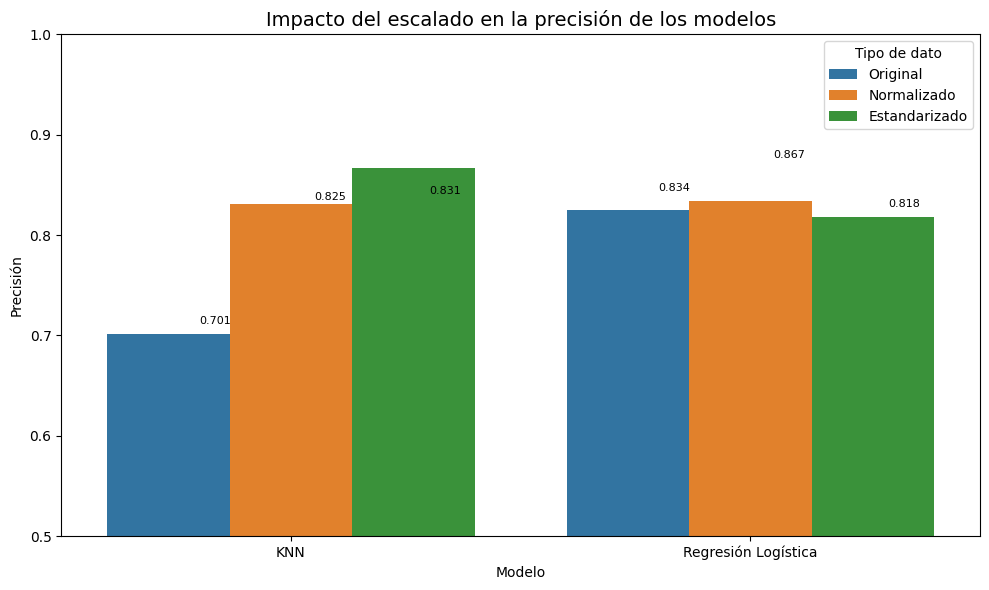

In [56]:
# Creamos un DataFrame para comparar las precisiones
# obtenidas por cada modelo con diferentes tipos de escalado
comparativa = pd.DataFrame({
    'Modelo': ['KNN', 'Regresión Logística'],
    
    # Resultados usando datos originales
    'Original': [
        resultados['Original'][0],
        resultados['Original'][1]
    ],
    
    # Resultados usando datos normalizados
    'Normalizado': [
        resultados['Normalizado'][0],
        resultados['Normalizado'][1]
    ],
    
    # Resultados usando datos estandarizados
    'Estandarizado': [
        resultados['Estandarizado'][0],
        resultados['Estandarizado'][1]
    ]
})

# Mostramos la tabla comparativa de precisiones
print("\n=== TABLA COMPARATIVA DE PRECISIONES ===")
print(comparativa)

# Convertimos el DataFrame a formato largo
# para facilitar la visualización con seaborn
comparativa_melt = comparativa.melt(
    id_vars='Modelo',
    var_name='Escalado',
    value_name='Precisión'
)

# Creamos una figura para el gráfico comparativo
plt.figure(figsize=(10, 6))

# Generamos gráfico de barras comparando precisiones
sns.barplot(
    data=comparativa_melt,
    x='Modelo',
    y='Precisión',
    hue='Escalado'
)

# Título del gráfico
plt.title('Impacto del escalado en la precisión de los modelos', fontsize=14)

# Definimos límites del eje Y
plt.ylim(0.5, 1.0)

# Etiqueta del eje Y
plt.ylabel('Precisión')

# Mostramos la leyenda
plt.legend(title='Tipo de dato')

# Agregamos los valores de precisión encima de cada barra
for i, (modelo, escala, precision) in enumerate(
    zip(
        comparativa_melt['Modelo'],
        comparativa_melt['Escalado'],
        comparativa_melt['Precisión']
    )
):
    plt.text(
        i//3 + (i%3)*0.25 - 0.2,
        precision + 0.01,
        f'{precision:.3f}',
        fontsize=8
    )

# Ajustamos automáticamente el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()

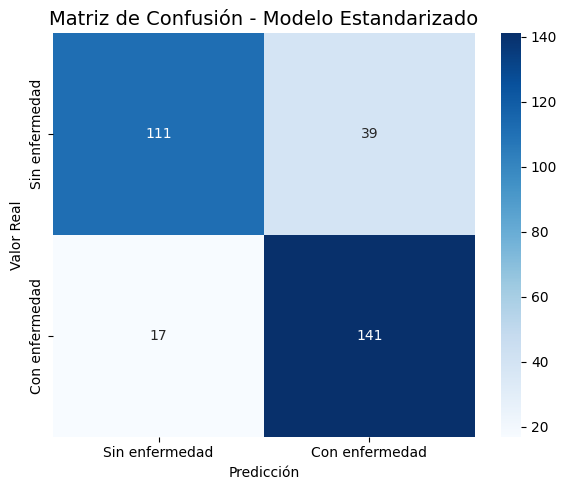


=== REPORTE DE CLASIFICACIÓN ===
                precision    recall  f1-score   support

Sin enfermedad       0.87      0.74      0.80       150
Con enfermedad       0.78      0.89      0.83       158

      accuracy                           0.82       308
     macro avg       0.83      0.82      0.82       308
  weighted avg       0.82      0.82      0.82       308



In [57]:
# Utilizamos el mejor modelo identificado:
# Regresión Logística con datos estandarizados
mejor_modelo = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento estandarizados
mejor_modelo.fit(X_train_std, y_train)

# Realizamos predicciones con los datos de prueba
y_pred_mejor = mejor_modelo.predict(X_test_std)

# ---------------- MATRIZ DE CONFUSIÓN ----------------
# Calculamos la matriz de confusión para evaluar el rendimiento
cm = confusion_matrix(y_test, y_pred_mejor)

# Creamos una figura para visualizar la matriz
plt.figure(figsize=(6, 5))

# Generamos mapa de calor de la matriz de confusión
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    
    # Etiquetas de las clases
    xticklabels=['Sin enfermedad', 'Con enfermedad'],
    yticklabels=['Sin enfermedad', 'Con enfermedad']
)

# Título del gráfico
plt.title('Matriz de Confusión - Modelo Estandarizado', fontsize=14)

# Etiquetas de los ejes
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

# Ajustamos automáticamente el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()

# ---------------- REPORTE DE CLASIFICACIÓN ----------------
# Mostramos métricas de evaluación:
# precisión, recall, f1-score y soporte
print("\n=== REPORTE DE CLASIFICACIÓN ===")

print(
    classification_report(
        y_test,
        y_pred_mejor,
        target_names=['Sin enfermedad', 'Con enfermedad']
    )
)

## CONCLUSIONES DEL ANÁLISIS CLÍNICO

Las variables clínicas presentan diferentes escalas numéricas, lo que puede afectar el rendimiento de los modelos de Machine Learning, especialmente aquellos basados en distancias.

Por ejemplo:
- El colesterol posee valores mucho mayores que la edad o la presión arterial.
- Esto provoca que algunas variables tengan más influencia en el modelo debido únicamente a su magnitud numérica.

Se comparó el rendimiento de los modelos utilizando:
- Datos originales
- Datos normalizados
- Datos estandarizados

El modelo KNN mostró una mejora considerable después de aplicar técnicas de escalado, especialmente con estandarización.

La Regresión Logística también presentó mejoras en estabilidad y precisión tras el preprocesamiento de los datos.

Para aplicaciones médicas, se recomienda aplicar técnicas de normalización o estandarización antes de entrenar modelos predictivos.

Un modelo entrenado sin preprocesamiento adecuado podría generar:
- Diagnósticos incorrectos
- Falsos positivos o falsos negativos
- Mala interpretación de variables clínicas

En conclusión, el preprocesamiento de datos es un paso fundamental para mejorar la precisión, estabilidad y confiabilidad de modelos utilizados en diagnósticos médicos.

# IMPLEMENTACION DE DUMMY Y SVC PARA CORROBORAR QUE LOS DATOS ESTEN BIEN Y USARLOS EN VS CODE CON INTERFAZ


In [58]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
import pickle
import os

In [59]:
# ========== DUMMY CLASSIFIER ==========
dummy = DummyClassifier(strategy='prior', random_state=42)
dummy.fit(X_train_std, y_train)
acc_dummy = dummy.score(X_test_std, y_test)
print(f"Dummy Accuracy: {acc_dummy:.4f}")

Dummy Accuracy: 0.5130


In [60]:
# ========== SVC ==========
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_std, y_train)
acc_svc = svc.score(X_test_std, y_test)
print(f"SVC Accuracy: {acc_svc:.4f}")

SVC Accuracy: 0.9058


In [61]:
# ========== GUARDAR MODELOS ==========
os.makedirs('models', exist_ok=True)


In [62]:
# Guardar SVC (mejor que Dummy)
with open('models/model_svc.pkl', 'wb') as f:
    pickle.dump(svc, f)

In [63]:
# Guardar el scaler que ya tienes
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(standardizer, f)

print("✅ Modelo SVC y Scaler guardados en carpeta 'models'")

✅ Modelo SVC y Scaler guardados en carpeta 'models'


# IMAGENES DE LA INTERFAZ GRAFICA PARA LAS ENFERMEDADES CARDIACAS

![Logo](img/interfaz1.png)

![Logo](img/interfaz1.1.png)

![Logo](img/interfaz2.png)

# AUSENTES


![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 06/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **

In [64]:
import numpy as np
from sklearn.impute import SimpleImputer

In [65]:
# Carga de datos
X_train = [[1,      4], 
           [np.nan, 3], 
           [7,      8]]

In [66]:
# Limpieza de datos: imputación valores ausentes (modelo)
imputer = SimpleImputer(strategy='mean') # Utilizamos la estrategia de la media

# Aplicar los métodos "fit" y "transform" para imputar los valores pérdidos de X_train
X_train_clean = imputer.fit_transform(X_train)
print(X_train_clean)

[[1. 4.]
 [4. 3.]
 [7. 8.]]


In [67]:
# Imputación de valores ausentes sobre el conjunto de test
X_test = [[np.nan, 10], 
          [6,      np.nan], 
          [8,      2]]

# Imputar los datos del conjunto de test
X_test_clean=imputer.transform(X_test)
print(X_test_clean)

[[ 4. 10.]
 [ 6.  5.]
 [ 8.  2.]]


# SELECCION ATRIBUTOS


![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 07/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **

In [68]:
import numpy as np
from sklearn.feature_selection import VarianceThreshold

In [69]:
# Carga de datos.
X = [[0, 0, 1], [0, 1, 0], [1, 0, 0],
     [0, 1, 1], [0, 1, 0], [0, 1, 1]]
print(X)

[[0, 0, 1], [0, 1, 0], [1, 0, 0], [0, 1, 1], [0, 1, 0], [0, 1, 1]]


In [70]:
# Limpieza de datos: selección de atributos.

# fijamos un umbral (th) para decidir qué porcentaje mínimo deben variar los valores de una columna para considerarse 
# una columna relevante a la hora de mantenerla en nuestro estudio
th = 0.2
sel = VarianceThreshold(th)
print(sel.fit_transform(X))

[[0 1]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]]


# SELECCION ATRIBUTOS 2

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression, mutual_info_regression

In [72]:
# Carga de datos.
np.random.seed(42)
X = np.random.rand(1000, 3)
print(X)
print(np.shape(X))

[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 ...
 [0.80000348 0.55270708 0.39655368]
 [0.13171503 0.86529576 0.15727321]
 [0.30978786 0.29004553 0.87141403]]
(1000, 3)


In [73]:
# Definimos la etiqueta (target, ground truth) haciéndola dependiente de las características x1 y x2
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000)

In [74]:
# Evaluación de atributos: F-Test.
f_test, _ = f_regression(X, y) # Llamamos al estadístico F
f_test /= np.max(f_test) # Normalizamos

In [75]:
# Evaluación de atributos: información mutua.
mi = mutual_info_regression(X, y)
mi /= np.max(mi)

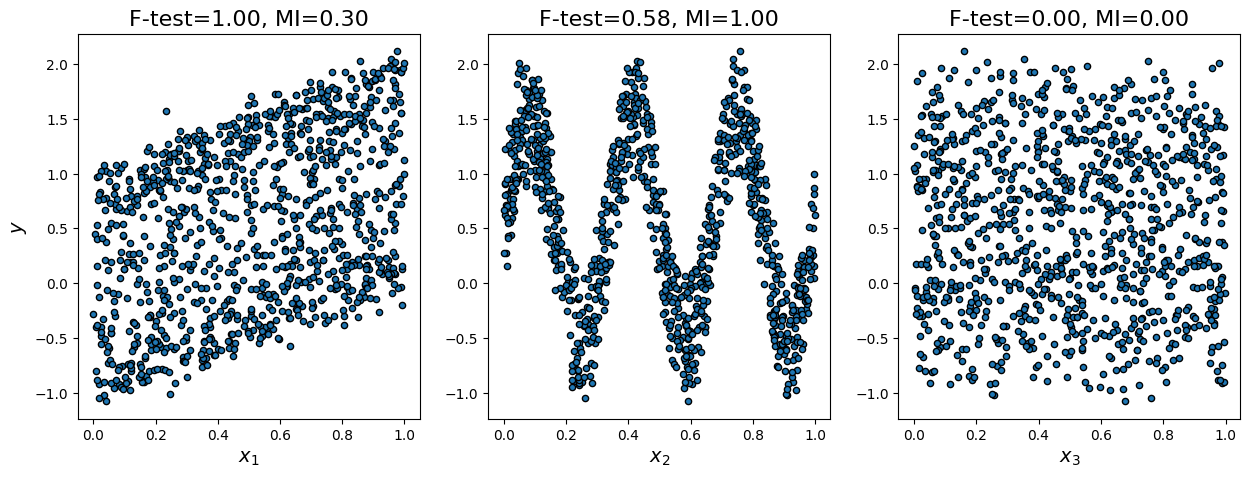

In [76]:
# Graficamos la distribución de los datos y evaluación de atributos.
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, i], y, edgecolor='black', s=20)
    plt.xlabel("$x_{}$".format(i + 1), fontsize=14)
    if i == 0:
        plt.ylabel("$y$", fontsize=14)
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i],
              mi[i]), fontsize=16)
plt.show()

# HOLD OUT Y EJERCICIO PRACTICO

![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 12/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **

In [77]:
import numpy as np
from sklearn import datasets
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [78]:
# Carga de datos
iris = datasets.load_iris()
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [79]:
# Mostrar características de la tabla de datos.
print("Tabla de datos: %d instancias y %d atributos" % (iris.data.shape[0], iris.data.shape[1]))
print("Valores de la clase:", set(iris.target))

# Cuantificamos el número de instancias que contiene el dataset por clase
valores, ocurrencias = np.unique(iris.target, return_counts=True)
print(valores, ocurrencias)

Tabla de datos: 150 instancias y 4 atributos
Valores de la clase: {np.int64(0), np.int64(1), np.int64(2)}
[0 1 2] [50 50 50]


In [80]:
# Test: hold-out split 80-20%. # Partición externa
X_training, X_test, y_training, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
valores_test, ocur_test = np.unique(y_test, return_counts=True)
print('Test: ', 'clases:', valores_test, ' ocurrencias: ', ocur_test)

Test:  clases: [0 1 2]  ocurrencias:  [10  9 11]


In [81]:
# Estandarizar las características de entrenamiento y de test
standardizer = StandardScaler()
X_training = standardizer.fit_transform(X_training)
X_test = standardizer.transform(X_test)

In [82]:
# Validación: hold-out split 80-20%. # Partición interna
X_train, X_val, y_train, y_val = train_test_split(X_training, y_training, test_size=0.2, random_state=42)
valores_train, ocur_train = np.unique(y_train, return_counts=True)
print('Entrenamiento: ', ' clases:', valores_train, '  ocurrencias:', ocur_train)

valores_val, ocur_val = np.unique(y_val, return_counts=True)
print('Validation:    ', ' clases:', valores_val, '  ocurrencias:', ocur_val)

Entrenamiento:   clases: [0 1 2]   ocurrencias: [32 30 34]
Validation:      clases: [0 1 2]   ocurrencias: [ 8 11  5]


In [83]:
# Construcción del objeto que contiene el algoritmo de aprendizaje.
clf = DummyClassifier(strategy='prior', random_state=42)

In [84]:
# Entrenamiento del algoritmo de aprendizaje.
clf = clf.fit(X_train, y_train)

In [85]:
# Evaluación del algoritmo de aprendizaje con el método "score" que devuelve directamente la métrica de 'accuracy'
val_accuracy = clf.score(X_val, y_val)
print("Exactitud en validación: ", val_accuracy)

test_accuracy = clf.score(X_test, y_test)
print("Exactitud en test: ", test_accuracy)

Exactitud en validación:  0.20833333333333334
Exactitud en test:  0.36666666666666664


In [86]:
# Obtenemos las predicciones sobre conjunto de validación y de test
y_pred_val = clf.predict(X_val)
print('Predicciones de validación ', y_pred_val)
print('Etiquetas reales validación', y_val)

y_pred_test = clf.predict(X_test)
print('\nPredicciones de test ', y_pred_val)
print('Etiquetas reales test', y_val)


Predicciones de validación  [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Etiquetas reales validación [1 1 0 0 0 2 1 2 2 2 1 1 1 1 1 0 2 0 1 0 1 1 0 0]

Predicciones de test  [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Etiquetas reales test [1 1 0 0 0 2 1 2 2 2 1 1 1 1 1 0 2 0 1 0 1 1 0 0]


In [87]:
# Aplicamos un ejemplo con un clasificador más complejo que el "dummyclassifier"
from sklearn.svm import SVC
svc = SVC(C=0.5) # Definimos algoritmo
svc.fit(X_train, y_train) # Entrenamos modelo

val_accuracy = svc.score(X_val, y_val) # Evaluamos modelo en validación
print('Exactitud en validación ', np.round(val_accuracy*100, 4), '%')

test_accuracy = svc.score(X_test, y_test) # Evaluamos modelo en test
print('Exactitud en test ', np.round(test_accuracy*100, 4), '%')

Exactitud en validación  91.6667 %
Exactitud en test  96.6667 %


In [88]:
# Guardar modelo
import pickle
with open('models/model.pkl', 'wb') as fw:
    pickle.dump(svc, fw)

# Cargar modelo
with open('models/model.pkl', 'rb') as fr:
    modelo = pickle.load(fr)
print ("modelo cargado")

# Guardamos el escalado
with open ('models/scaler.pkl', 'wb' ) as fw:
    pickle.dump(standardizer, fw)

# Cargamos el scaler
with open ('models/scaler.pkl', 'rb' ) as f:
    scaler_cargado = pickle.load(f)

print ("Modelo y scaler cargados")

modelo cargado
Modelo y scaler cargados


In [100]:
import pickle

# Usar tu ruta completa de Windows
with open(r'C:/Users/ESTUDIANTES-ITQ/Desktop/cuadernoIA2026/cuadernoIA2026\models\model.pkl', 'wb') as fw:
    pickle.dump(svc, fw)

print("Modelo guardado exitosamente")

# Cargar modelo
with open(r'C:/Users/ESTUDIANTES-ITQ/Desktop/cuadernoIA2026/cuadernoIA2026\models\model.pkl', 'rb') as fr:
    loaded_model = pickle.load(fr)

print("Modelo cargado exitosamente")

Modelo guardado exitosamente
Modelo cargado exitosamente


In [101]:
# Nuevos datos

nuevo_dato = [[8.5, 2.6, 4.1, 8.8]]
#Escalo los datos 
nuevo_dato_escalado = scaler_cargado.transform(nuevo_dato)
print(nuevo_dato_escalado)

[[ 3.28004265 -1.0322392   0.21394119 10.16710995]]


In [102]:
#Prediccion
prediccion = modelo.predict(nuevo_dato_escalado)
print(prediccion)

[2]


In [103]:
if prediccion == 0:
    print("la flor q se predijo es: ", 0 , "setosa")
elif prediccion == 1:
    print("la flor q se predijo es: ", 1 , "versicolor")
else:
    print("la flor q se predijo es: ", 2 , "virginica")



la flor q se predijo es:  2 virginica


In [105]:
print("escribe las caracteristicas de la flor")

# Solicita cada valor individualmente
sepal_length = float(input("ingresa el tamaño del sepalo(cm): "))
sepal_width = float(input("ingresa el ancho del sepalo(cm): "))
petal_length = float(input("ingresa el tamaño del petalo (cm): "))
petal_width = float(input("ingresa el ancho del petalo(cm): "))

# Crea el nuevo dato con los valores ingresados
nuevo_dato = [[sepal_length, sepal_width, petal_length, petal_width]]

# Escala los datos
nuevo_dato_escalado = scaler_cargado.transform(nuevo_dato)
print(nuevo_dato_escalado)

# Prediccion de los datos
prediccion = modelo.predict(nuevo_dato_escalado)
print(prediccion)

# Imprime los datos 
if prediccion == 0:
    print("la flor q se predijo es: ", 0 , "setosa")
elif prediccion == 1:
    print("la flor q se predijo es: ", 1 , "versicolor")
else:
    print("la flor q se predijo es: ", 2 , "virginica")



escribe las caracteristicas de la flor


ingresa el tamaño del sepalo(cm):  5.3
ingresa el ancho del sepalo(cm):  2.1
ingresa el tamaño del petalo (cm):  0.6
ingresa el ancho del petalo(cm):  1.1


[[-0.62065843 -2.15018779 -1.79175745 -0.11123753]]
[1]
la flor q se predijo es:  1 versicolor


# IMPLEMENTACION DE INTERFAZ EN VS CODE PARA VER QUE TIPO DE FLOR ES

![logo](img/setosa1.png)

![Logo](img/setosa1.1.png)


![Logo](img/versicolor1.png)

![Logo](img/versicolor1.1.png)

![Logo](img/virginica1.png)

![Logo](img/virginica1.1.png)

# VALIDACION CRUZADA 1
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 20/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **







In [106]:
from sklearn.model_selection import KFold

In [107]:
# Carga de datos.
X = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]

In [108]:
# Validación cruzada.
kf = KFold(n_splits = 5, shuffle=True) # Shuffle permite aleatorizar las bolsas de test vez de hacer una lectura por orden 
bolsas = kf.split(X)
print(bolsas)

<generator object _BaseKFold.split at 0x000002A71352A790>


In [109]:
# Mostrar ejemplos de cada iteración.
k = 1
for train, test in bolsas:
    print("Iteracion", k, ":")
    print(" - Entrenamiento: %s" % (train)) 
    print(" - Test: %s" % (test))
    k = k + 1

Iteracion 1 :
 - Entrenamiento: [0 2 4 5 6 7 8 9]
 - Test: [1 3]
Iteracion 2 :
 - Entrenamiento: [0 1 2 3 4 6 7 9]
 - Test: [5 8]
Iteracion 3 :
 - Entrenamiento: [1 2 3 4 5 6 7 8]
 - Test: [0 9]
Iteracion 4 :
 - Entrenamiento: [0 1 3 4 5 7 8 9]
 - Test: [2 6]
Iteracion 5 :
 - Entrenamiento: [0 1 2 3 5 6 8 9]
 - Test: [4 7]


# VALIDACION CRUZADA 2

In [110]:
import numpy as np
from sklearn import datasets
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [111]:
# Carga de datos.
iris = datasets.load_iris()
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [112]:
# Mostrar características de la tabla de datos.
print("Tabla de datos: %d instancias y %d atributos" % (iris.data.shape[0], iris.data.shape[1]))
print("Valores de la clase:", set(iris.target))

Tabla de datos: 150 instancias y 4 atributos
Valores de la clase: {np.int64(0), np.int64(1), np.int64(2)}


In [113]:
# Test: hold-out split 80-20%. PARTICIÓN EXTERNA
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)  # CORREGIDO: x_text → x_test
valores_test, ocur_test = np.unique(y_test, return_counts=True)
print('Test:', 'clases:', valores_test, 'ocurrencias: ', ocur_test)


Test: clases: [0 1 2] ocurrencias:  [10  9 11]


In [114]:
# Estandarizar las características de entrenamiento y de test
standardizer = StandardScaler()
x_train = standardizer.fit_transform(x_train)  # CORREGIDO: x_train ya existe
x_test = standardizer.transform(x_test)

In [115]:
# Definimos el algoritmo SVM para clasificación
from sklearn.svm import SVC
svc = SVC(C=0.5, gamma='auto')

# Hacemos el cross-validation interno para seleccionar los mejores hiperparámetros
results = cross_val_score(svc, x_train, y_train, cv = KFold(n_splits=5))  # CORREGIDO: X_train → x_train
print("Resultados por bolsa: ", results)
print("Accuracy (media +/- desv.): %0.4f +/- %0.4f" % (results.mean(), results.std()))

Resultados por bolsa:  [0.95833333 0.95833333 0.83333333 0.95833333 0.95833333]
Accuracy (media +/- desv.): 0.9333 +/- 0.0500


In [116]:
# Una vez entrenado y validado el modelo para seleccionar los mejores hyperparameters, utilizamos todos los datos de 
# "train" y "val" para entrenar el modelo definitivo

# svc = ???

# Entrenamos el modelo con todos los datos de entrenamiento
svc.fit(x_train, y_train)  # ← PARTE LLENADA


,C,0.5
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [117]:
# Calcular la accuracy del conjunto de test
test_results = svc.score(x_test, y_test)  # ← PARTE LLENADA
print('Exactitud en test: ', test_results*100, '%')

Exactitud en test:  100.0 %


In [118]:
# Extraer las predicciones, en lugar de directamente la accuracy
y_pred = svc.predict(x_test)  # ← PARTE LLENADA
print('Predicciones:     ', y_pred)
print('Etiquetas reales: ', y_test)

Predicciones:      [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Etiquetas reales:  [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# VARIABLES CUALITATIVAS
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 21/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **







In [119]:
# Creación aleatoria de datos
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(42)

In [120]:
nivel_estudios = []
nivel_estudios.extend(['Secundaria']*110)
nivel_estudios.extend(['Bachillerato']*172)
nivel_estudios.extend(['Grado']*145)
nivel_estudios.extend(['Master']*52)
nivel_estudios.extend(['Doctorado']*21)
nivel_estudios = np.random.permutation(nivel_estudios)

In [121]:
print(nivel_estudios)

['Bachillerato' 'Bachillerato' 'Bachillerato' 'Grado' 'Bachillerato'
 'Bachillerato' 'Grado' 'Doctorado' 'Secundaria' 'Grado' 'Grado'
 'Bachillerato' 'Master' 'Bachillerato' 'Bachillerato' 'Grado' 'Grado'
 'Bachillerato' 'Bachillerato' 'Master' 'Grado' 'Grado' 'Secundaria'
 'Grado' 'Bachillerato' 'Bachillerato' 'Bachillerato' 'Master'
 'Secundaria' 'Grado' 'Grado' 'Secundaria' 'Grado' 'Bachillerato' 'Grado'
 'Bachillerato' 'Master' 'Grado' 'Master' 'Bachillerato' 'Master' 'Master'
 'Grado' 'Secundaria' 'Secundaria' 'Bachillerato' 'Master' 'Bachillerato'
 'Grado' 'Grado' 'Bachillerato' 'Secundaria' 'Doctorado' 'Doctorado'
 'Bachillerato' 'Grado' 'Bachillerato' 'Bachillerato' 'Grado' 'Secundaria'
 'Bachillerato' 'Bachillerato' 'Secundaria' 'Secundaria' 'Master' 'Master'
 'Grado' 'Doctorado' 'Bachillerato' 'Bachillerato' 'Grado' 'Master'
 'Grado' 'Grado' 'Bachillerato' 'Secundaria' 'Secundaria' 'Bachillerato'
 'Secundaria' 'Bachillerato' 'Master' 'Grado' 'Bachillerato' 'Secundaria'
 'Bach

In [122]:
# importacion de librerias matplotlib y numpy
import matplotlib.pyplot as plt
import numpy as np

# CALCULAR FRECUENCIA DE CADA NIVEL
estudios, frecuencia = np.unique(nivel_estudios, return_counts=True)
print(f"\nNiveles de estudio: {estudios}")
print(f"Frecuencias: {frecuencia}")


Niveles de estudio: ['Bachillerato' 'Doctorado' 'Grado' 'Master' 'Secundaria']
Frecuencias: [172  21 145  52 110]


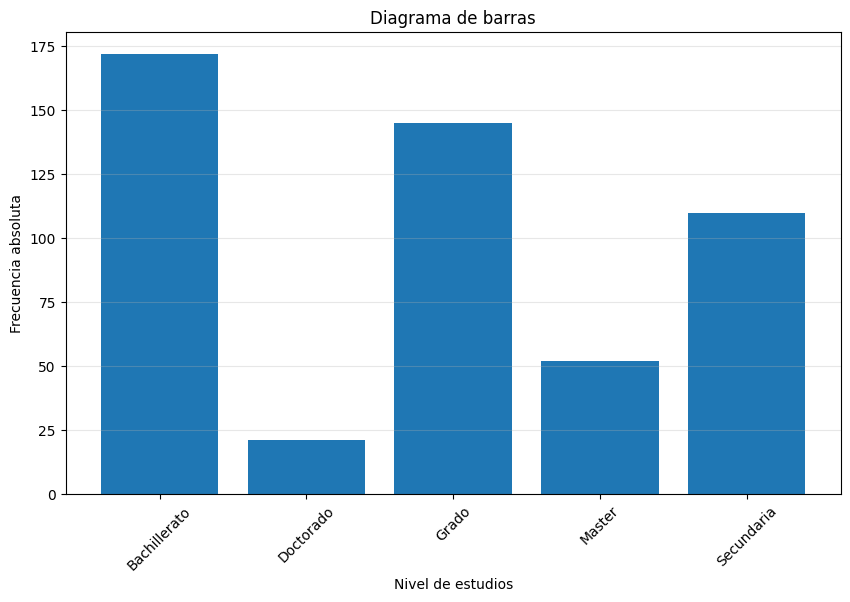

In [123]:
# DIAGRAMA DE BARRAS

plt.figure(figsize=(10, 6))
plt.ylabel('Frecuencia absoluta')
plt.xlabel('Nivel de estudios')
plt.title('Diagrama de barras')
plt.bar(estudios, frecuencia) # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()




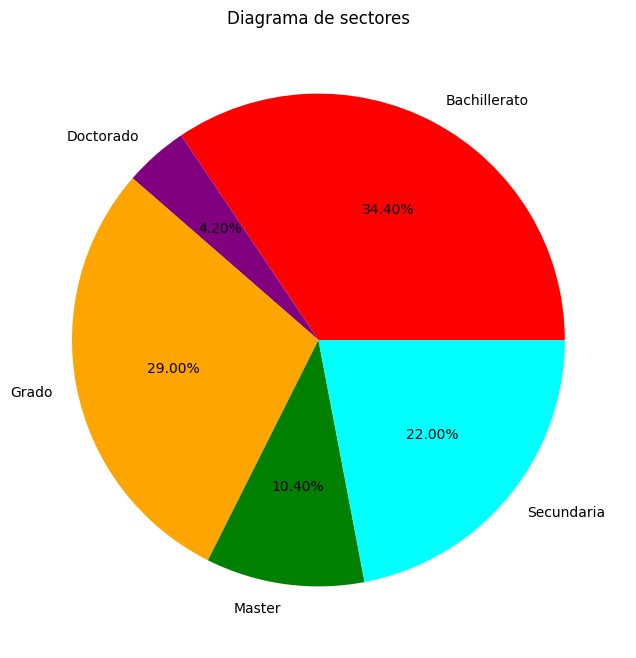

In [124]:
# DIAGRAMA DE SECTORES
plt.figure(figsize=(8, 8))
colores = ['red', 'purple', 'orange', 'green', 'cyan']
plt.pie(frecuencia, labels=estudios, colors=colores, autopct='%1.2f%%')
plt.title('Diagrama de sectores')
plt.show()

In [125]:
# Tarea implementar con pandas esta información implementar esto con un dataframe

In [126]:
# 1. IMPORTAR PANDAS
import pandas as pd

print("\n" + "="*50)
print("IMPLEMENTACIÓN CON DATAFRAME DE PANDAS")
print("="*50)


IMPLEMENTACIÓN CON DATAFRAME DE PANDAS


In [127]:
# 2. CREAR DATAFRAME A PARTIR DE LOS DATOS QUE YA TENÍAS
#    Un DataFrame es como una tabla (filas y columnas)
df = pd.DataFrame({
    'nivel_estudios': nivel_estudios  # Usamos la lista que ya creaste
})

print("\n📊 DATAFRAME CREADO (primeras 10 filas):")
print(df.head(10))



📊 DATAFRAME CREADO (primeras 10 filas):
  nivel_estudios
0   Bachillerato
1   Bachillerato
2   Bachillerato
3          Grado
4   Bachillerato
5   Bachillerato
6          Grado
7      Doctorado
8     Secundaria
9          Grado


In [128]:
# 3. CALCULAR FRECUENCIA ABSOLUTA CON PANDAS
#    value_counts() cuenta cuántas veces aparece cada categoría
frec_absoluta = df['nivel_estudios'].value_counts()

print("\n✅ FRECUENCIA ABSOLUTA:")
print(frec_absoluta)


✅ FRECUENCIA ABSOLUTA:
nivel_estudios
Bachillerato    172
Grado           145
Secundaria      110
Master           52
Doctorado        21
Name: count, dtype: int64


In [129]:
# 4. CALCULAR FRECUENCIA RELATIVA (PORCENTAJES)
#    normalize=True hace que sume 1, luego lo multiplicamos por 100
frec_relativa = df['nivel_estudios'].value_counts(normalize=True) * 100

print("\n✅ FRECUENCIA RELATIVA (%):")
print(frec_relativa.round(2))


✅ FRECUENCIA RELATIVA (%):
nivel_estudios
Bachillerato    34.4
Grado           29.0
Secundaria      22.0
Master          10.4
Doctorado        4.2
Name: proportion, dtype: float64


In [130]:
# 5. CREAR UNA TABLA DE FRECUENCIAS COMPLETA
tabla_frecuencias = pd.DataFrame({
    'Nivel': frec_absoluta.index,
    'Frecuencia_Absoluta': frec_absoluta.values,
    'Frecuencia_Relativa(%)': frec_relativa.round(2).values
})

print("\n✅ TABLA DE FRECUENCIAS COMPLETA:")
print(tabla_frecuencias.to_string(index=False))



✅ TABLA DE FRECUENCIAS COMPLETA:
       Nivel  Frecuencia_Absoluta  Frecuencia_Relativa(%)
Bachillerato                  172                    34.4
       Grado                  145                    29.0
  Secundaria                  110                    22.0
      Master                   52                    10.4
   Doctorado                   21                     4.2


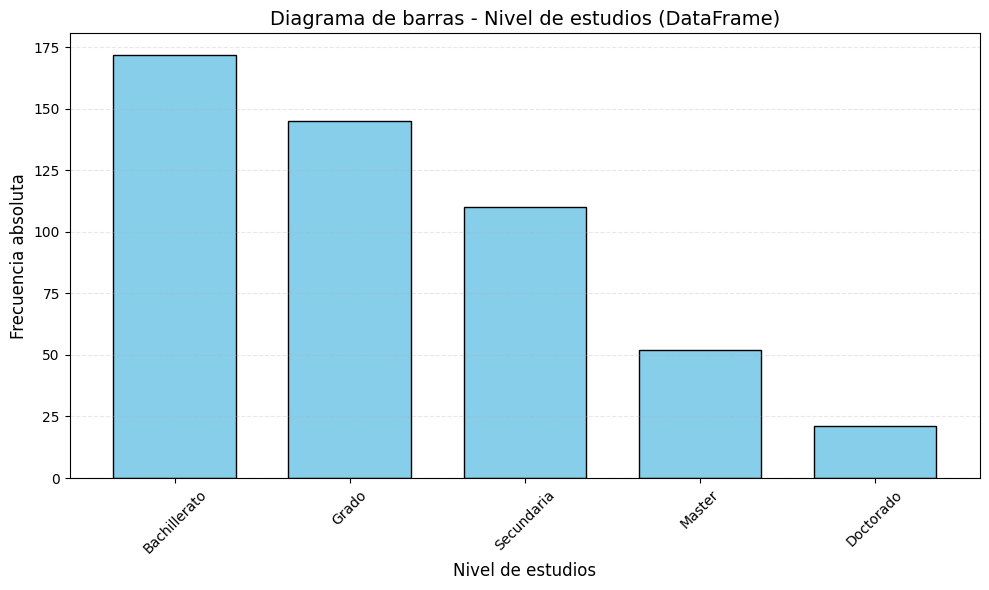

In [131]:
# 6. DIAGRAMA DE BARRAS CON PANDAS
#    plot(kind='bar') es el método de pandas para hacer barras
plt.figure(figsize=(10, 6))
frec_absoluta.plot(kind='bar', color='skyblue', edgecolor='black', width=0.7)
plt.ylabel('Frecuencia absoluta', fontsize=12)
plt.xlabel('Nivel de estudios', fontsize=12)
plt.title('Diagrama de barras - Nivel de estudios (DataFrame)', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

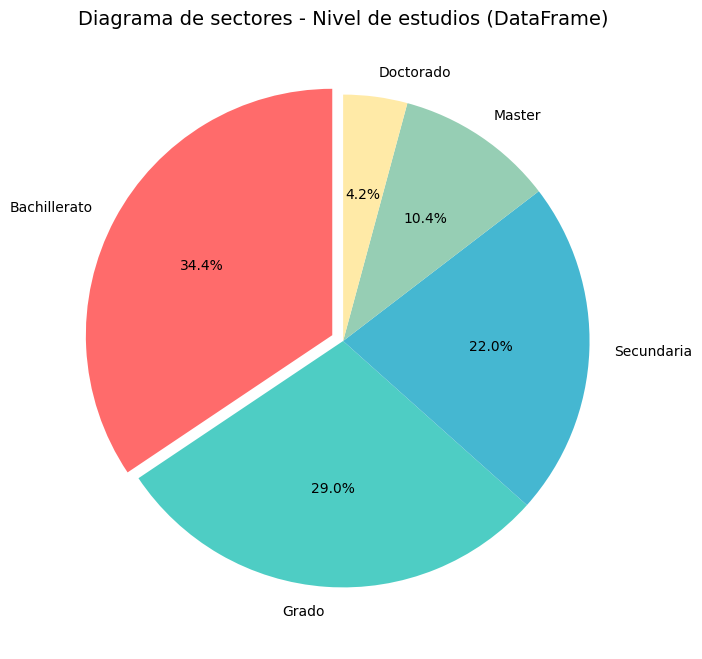

In [132]:
# 7. DIAGRAMA DE SECTORES CON PANDAS
#    Usamos los mismos datos pero desde el DataFrame
plt.figure(figsize=(8, 8))
colores_personalizados = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
plt.pie(frec_absoluta.values, 
        labels=frec_absoluta.index, 
        colors=colores_personalizados, 
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0, 0, 0, 0))
plt.title('Diagrama de sectores - Nivel de estudios (DataFrame)', fontsize=14)
plt.show()


In [133]:
# 8. INFORMACIÓN EXTRA DEL DATAFRAME
print("\n✅ INFORMACIÓN DEL DATAFRAME:")
print(f"Total de registros: {len(df)}")
print(f"Niveles únicos: {df['nivel_estudios'].nunique()}")
print(f"Categorías: {df['nivel_estudios'].unique()}")
print(f"Nivel más común (moda): {df['nivel_estudios'].mode()[0]}")


✅ INFORMACIÓN DEL DATAFRAME:
Total de registros: 500
Niveles únicos: 5
Categorías: <StringArray>
['Bachillerato', 'Grado', 'Doctorado', 'Secundaria', 'Master']
Length: 5, dtype: str
Nivel más común (moda): Bachillerato


In [134]:
# 9. FILTRAR DATOS CON PANDAS
#    Esto es algo que NO se podía hacer fácilmente con listas
df_grado_superior = df[df['nivel_estudios'].isin(['Grado', 'Master', 'Doctorado'])]
print(f"\n🎓 Personas con Grado o superior: {len(df_grado_superior)}")
print(f"Porcentaje: {(len(df_grado_superior)/len(df)*100):.1f}%")


🎓 Personas con Grado o superior: 218
Porcentaje: 43.6%


In [135]:
# 10. AGREGAR NUEVAS COLUMNAS AL DATAFRAME
#     Añadimos ID y edad como ejemplo
df['id'] = range(1, len(df) + 1)
np.random.seed(42)
df['edad'] = np.random.randint(18, 66, size=len(df))

print("\n📋 DATAFRAME CON NUEVAS COLUMNAS:")
print(df.head(10))


📋 DATAFRAME CON NUEVAS COLUMNAS:
  nivel_estudios  id  edad
0   Bachillerato   1    56
1   Bachillerato   2    46
2   Bachillerato   3    32
3          Grado   4    60
4   Bachillerato   5    25
5   Bachillerato   6    38
6          Grado   7    56
7      Doctorado   8    36
8     Secundaria   9    40
9          Grado  10    28


In [136]:
# 11. ESTADÍSTICAS DE EDAD POR NIVEL DE ESTUDIOS
print("\n📊 EDAD PROMEDIO POR NIVEL DE ESTUDIOS:")
print(df.groupby('nivel_estudios')['edad'].mean().round(1))



📊 EDAD PROMEDIO POR NIVEL DE ESTUDIOS:
nivel_estudios
Bachillerato    40.8
Doctorado       41.4
Grado           43.3
Master          39.7
Secundaria      43.2
Name: edad, dtype: float64


In [137]:
# 12. EXPORTAR DATAFRAME A CSV (OPCIONAL)
df.to_csv('nivel_estudios_completo.csv', index=False, encoding='utf-8')
print("\n💾 DataFrame exportado a 'nivel_estudios_completo.csv'")

print("\n" + "="*50)
print("🎉 FIN DE LA IMPLEMENTACIÓN CON DATAFRAME")
print("="*50)


💾 DataFrame exportado a 'nivel_estudios_completo.csv'

🎉 FIN DE LA IMPLEMENTACIÓN CON DATAFRAME
